<a href="https://colab.research.google.com/github/PC-Tam/GTSRB-DeepLearning-Classification/blob/main/notebooks/section1_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install torch torchvision
%pip install pandas numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
from torchvision import datasets
from sklearn.model_selection import train_test_split

BASE_DIR = r'C:\Bài\Deep Learning\GTSRB-DeepLearning-Classification-main'
gtsrb_root = os.path.join(BASE_DIR, 'data', 'raw')

if __name__ == '__main__':

    train_dir = None
    for root, dirs, files in os.walk(gtsrb_root):
        numeric_subdirs = [d for d in dirs if d.isdigit() or (d.startswith('0') and d.replace('0', '').isdigit())]
        if len(numeric_subdirs) >= 40:
            train_dir = root
            break

    if train_dir is None:
        all_folders = []
        for root, dirs, files in os.walk(gtsrb_root):
            for d in dirs:
                if d.isdigit() or (d.startswith('0') and d.replace('0', '').isdigit()):
                    all_folders.append(os.path.join(root, d))
        
        if all_folders:
            unique_parents = set(str(Path(p).parent) for p in all_folders)
            for parent in unique_parents:
                sub_count = len([d for d in os.listdir(parent) if os.path.isdir(os.path.join(parent, d)) and (d.isdigit() or (d.startswith('0') and d.replace('0', '').isdigit()))])
                if sub_count >= 30:
                    train_dir = parent
                    break

    if train_dir is None:
        raise FileNotFoundError(f"Không tìm thấy thư mục chứa các folder số của GTSRB bên trong {gtsrb_root}. Hãy chắc chắn rằng ông đã giải nén dữ liệu ảnh vào đây.")

    print("Thư mục huấn luyện gốc tìm thấy:", train_dir)

    raw_data = datasets.ImageFolder(train_dir)
    img_paths = [Path(img[0]).as_posix() for img in raw_data.imgs]

    targets = [int(Path(p).parent.name) for p in img_paths]

    train_idx, val_idx = train_test_split(
        np.arange(len(targets)),
        test_size=0.2,
        stratify=targets,
        random_state=42
    )

    SPLITS_DIR = os.path.join(BASE_DIR, 'data', 'splits')
    os.makedirs(SPLITS_DIR, exist_ok=True)

    pd.DataFrame({'path': [img_paths[i] for i in train_idx], 'label': [targets[i] for i in train_idx]}).to_csv(os.path.join(SPLITS_DIR, 'train.csv'), index=False)
    pd.DataFrame({'path': [img_paths[i] for i in val_idx], 'label': [targets[i] for i in val_idx]}).to_csv(os.path.join(SPLITS_DIR, 'val.csv'), index=False)

    unique_classes = sorted(list(set(targets)))
    class_mapping = {int(cls): f"{cls:05d}" if isinstance(cls, int) else str(cls) for cls in unique_classes}

    with open(os.path.join(SPLITS_DIR, 'class_mapping.json'), 'w') as f:
        json.dump(class_mapping, f, indent=4)

    print(f"Đã cập nhật dữ liệu và lưu vào {SPLITS_DIR}!")
    print(f"Tổng kết dữ liệu: Train = {len(train_idx)} ảnh | Val = {len(val_idx)} ảnh | Tổng số lớp = {len(unique_classes)}")

Thư mục huấn luyện gốc tìm thấy: C:\Bài\Deep Learning\GTSRB-DeepLearning-Classification-main\data\raw\Train
Đã cập nhật dữ liệu và lưu vào C:\Bài\Deep Learning\GTSRB-DeepLearning-Classification-main\data\splits!
Tổng kết dữ liệu: Train = 31367 ảnh | Val = 7842 ảnh | Tổng số lớp = 43


In [3]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

BASE_DIR = r'C:\Bài\Deep Learning\GTSRB-DeepLearning-Classification-main'
SPLITS_DIR = os.path.join(BASE_DIR, 'data', 'splits')

class GTSRBSharedDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label = int(self.df.iloc[idx]['label'])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        return image, label

if __name__ == '__main__':

    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(15),
        transforms.ColorJitter(0.2, 0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    train_set = GTSRBSharedDataset(csv_file=os.path.join(SPLITS_DIR, 'train.csv'), transform=train_transform)
    val_set = GTSRBSharedDataset(csv_file=os.path.join(SPLITS_DIR, 'val.csv'), transform=val_transform)

    train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2)

    print("DataLoader cho tập Train và Val đã xong")

DataLoader cho tập Train và Val đã xong


Đang lấy dữ liệu mẫu từ train_loader để hiển thị...


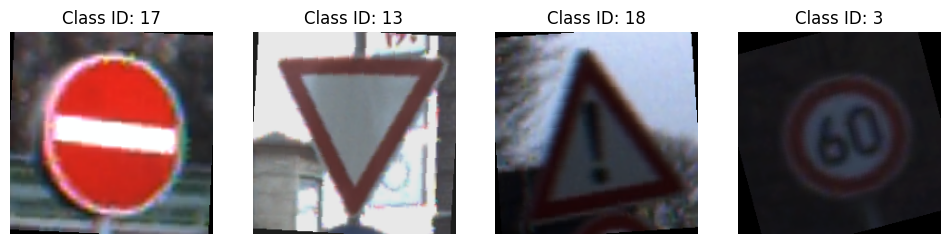

In [4]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = r'C:\Bài\Deep Learning\GTSRB-DeepLearning-Classification-main'
SPLITS_DIR = os.path.join(BASE_DIR, 'data', 'splits')

class GTSRBSharedDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label = int(self.df.iloc[idx]['label'])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        return image, label

if __name__ == '__main__':

    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(15),
        transforms.ColorJitter(0.2, 0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    train_set = GTSRBSharedDataset(csv_file=os.path.join(SPLITS_DIR, 'train.csv'), transform=train_transform)
    
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=0)

    print("Đang lấy dữ liệu mẫu từ train_loader để hiển thị...")
    
    images, labels = next(iter(train_loader))

    fig, axes = plt.subplots(1, 4, figsize=(12, 4))
    for i, ax in enumerate(axes):
        img = images[i].numpy().transpose((1, 2, 0))
        img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

        ax.imshow(img)
        ax.set_title(f"Class ID: {labels[i].item()}")
        ax.axis('off')

    plt.show()